
 # Counterfactual Inflation Analysis: What If Ukraine Had Been Part of the Euro Area?

 **Student:** Yoav Cohen

 **Course:** Quantitative Methods in Finance

 **Professor:** Eric Vansteenberghe

 **Institution:** Université Paris 1 Panthéon-Sorbonne
 
 **Academic year:** 2025–2026

 ## Objective

 This notebook constructs a counterfactual inflation path for Ukraine under
 the hypothesis that Ukraine had been part of the Euro Area.

 The core idea is to combine:
 1. A documented monetary-regime analysis for Ukraine;
 2. A Structural VAR (SVAR) framework with Cholesky identification;
 3. A counterfactual simulation in which Ukraine's idiosyncratic shocks are
    replaced by Euro Area demand conditions.

 **Estimation sample**: 2001M01–2021M12 (pre-war).
 The 2022+ wartime period is used only for an out-of-sample projection exercise.

In [262]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from scipy.linalg import cholesky

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# %%
# === PATHS ===
PROJECT_DIR = Path.cwd()
REPO_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"
OUT_DIR = PROJECT_DIR / "output"

FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

ECB_FILE = REPO_DIR / "data_ecb_hicp_panel.csv"
UKR_FILE = REPO_DIR / "data_ukraine_cpi_raw.csv"

print("ECB exists:", ECB_FILE.exists())
print("UKR exists:", UKR_FILE.exists())


# === UTILITY FUNCTIONS ===

def standardize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip().str.lower()
        .str.replace(" ", "_").str.replace("-", "_")
    )
    return df

def adf_table(series, name):
    s = series.dropna()
    stat, p, lags, nobs, crit, _ = adfuller(s, autolag="AIC")
    return pd.DataFrame({
        "Variable": [name],
        "ADF stat": [round(stat, 3)],
        "p-value": [round(p, 4)],
        "Lags": [lags],
        "N": [nobs],
        "1%": [round(crit["1%"], 3)],
        "5%": [round(crit["5%"], 3)],
        "Stationary (5%)": ["Yes" if p < 0.05 else "No"]
    })

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"  → Saved: {path.name}")


ECB exists: True
UKR exists: True


## 1. Part A : Monetary Regime Analysis

Ukraine has gone through several distinct monetary regimes since independence.
Understanding these regimes is essential for interpreting the counterfactual:
under Euro Area membership, Ukraine would lose both exchange-rate flexibility
and independent monetary policy.

## 1.1 Monetary regime table 

In [263]:
regime_table = pd.DataFrame([
    {"Period": "2000–2008",
     "Exchange rate": "Stable peg ≈ 5.0–5.3 UAH/USD",
     "De facto regime": "Fixed / stabilised arrangement",
     "Key features": "Limited monetary autonomy; low inflation imported via peg"},
    {"Period": "2008–2009",
     "Exchange rate": "Sharp devaluation (5.0 → 8.0)",
     "De facto regime": "Peg collapse / crisis adjustment",
     "Key features": "GFC contagion; banking crisis; IMF programme"},
    {"Period": "2010–2013",
     "Exchange rate": "Re-stabilised ≈ 8 UAH/USD",
     "De facto regime": "Managed peg",
     "Key features": "Exchange-rate anchor restored; fiscal pressures building"},
    {"Period": "2014–2015",
     "Exchange rate": "Massive devaluation (8 → 25+)",
     "De facto regime": "Crisis float / managed under stress",
     "Key features": "Crimea annexation; Donbas conflict; FX pass-through spike"},
    {"Period": "2016–2021",
     "Exchange rate": "Managed float (25–28 range)",
     "De facto regime": "Inflation targeting (IT)",
     "Key features": "NBU reform; 5%±1pp target; disinflation; credibility gains"},
    {"Period": "2022–present",
     "Exchange rate": "Wartime peg → gradual flexibilisation",
     "De facto regime": "Emergency controls / managed float",
     "Key features": "Full-scale invasion; capital controls; outside estimation sample"},
])

print("Table 1 — Ukraine Monetary Regime Classification\n")
display(regime_table)

Table 1 — Ukraine Monetary Regime Classification



,Period,Exchange rate,De facto regime,Key features
0,2000–2008,Stable peg ≈ 5.0–5.3 UAH/USD,Fixed / stabilised arrangement,Limited monetary autonomy; low inflation impor...
1,2008–2009,Sharp devaluation (5.0 → 8.0),Peg collapse / crisis adjustment,GFC contagion; banking crisis; IMF programme
2,2010–2013,Re-stabilised ≈ 8 UAH/USD,Managed peg,Exchange-rate anchor restored; fiscal pressure...
3,2014–2015,Massive devaluation (8 → 25+),Crisis float / managed under stress,Crimea annexation; Donbas conflict; FX pass-th...
4,2016–2021,Managed float (25–28 range),Inflation targeting (IT),NBU reform; 5%±1pp target; disinflation; credi...
5,2022–present,Wartime peg → gradual flexibilisation,Emergency controls / managed float,Full-scale invasion; capital controls; outside...


# **Structural comparison with the Euro Area**

Euro Area membership would imply three fundamental changes:

1. **Loss of exchange-rate flexibility.** Ukraine's high exchange-rate
pass-through (≈0.3–0.5 within a year) means that exchange-rate movements
are a major transmission channel for shocks. Under the euro, this
adjustment mechanism disappears.

2. **ECB-determined interest rates.** The ECB sets rates for the aggregate
euro area. Ukraine's cycle is only weakly correlated with the EA's,
so ECB rates may be systematically too loose or too tight for Ukraine.

3. **Credibility anchor.** The ECB's 2% inflation target and institutional
reputation could anchor expectations, reducing inflation persistence
— similar to what the NBU's IT reform partially achieved after 2016.

## 2. Data Loading & Processing


### 2.1 ECB HICP Panel 

In [264]:
ecb = pd.read_csv(ECB_FILE)
ecb = standardize_columns(ecb)
ecb = ecb.rename(columns={ecb.columns[0]: "time_period"})
ecb["date"] = pd.to_datetime(ecb["time_period"])

country_cols = ["at", "be", "de", "es", "fi", "fr", "gr", "ie", "it", "nl", "pt"]
for c in country_cols:
    ecb[c] = pd.to_numeric(ecb[c], errors="coerce")

# Euro Area average inflation (simple cross-country mean)
ecb["ea_inflation"] = ecb[country_cols].mean(axis=1)
ea = ecb[["date", "ea_inflation"]].sort_values("date").reset_index(drop=True)

print(f"ECB panel: {len(country_cols)} countries, {len(ea)} months")
print(f"  Range: {ea['date'].min().strftime('%Y-%m')} → {ea['date'].max().strftime('%Y-%m')}")


ECB panel: 11 countries, 312 months
  Range: 2000-01 → 2025-12


### 2.2 Ukraine CPI (MoM index → YoY inflation)

In [265]:
ukr = pd.read_csv(UKR_FILE)
ukr = standardize_columns(ukr)

# The raw file has time_period in col 9, obs_value in col 10
ukr = ukr.rename(columns={ukr.columns[9]: "time_period", ukr.columns[10]: "obs_value"})
ukr["date"] = pd.to_datetime(
    ukr["time_period"].astype(str).str.replace("-M", "-", regex=False),
    format="%Y-%m", errors="coerce"
)
ukr["cpi_mom"] = pd.to_numeric(ukr["obs_value"], errors="coerce")
ukr = ukr[["date", "cpi_mom"]].dropna().sort_values("date").reset_index(drop=True)

# MoM index (e.g. 101.5 = +1.5% MoM) → cumulative price level
ukr["price_level"] = 100 * (ukr["cpi_mom"] / 100).cumprod()

# Year-on-year inflation
ukr["ua_inflation"] = (ukr["price_level"] / ukr["price_level"].shift(12) - 1) * 100
ua = ukr[["date", "ua_inflation"]].dropna().reset_index(drop=True)

print(f"Ukraine inflation: {len(ua)} months")
print(f"  Range: {ua['date'].min().strftime('%Y-%m')} → {ua['date'].max().strftime('%Y-%m')}")



Ukraine inflation: 300 months
  Range: 2001-01 → 2025-12



### 2.3 Merge

In [266]:
df_full = ua.merge(ea, on="date", how="inner").sort_values("date").reset_index(drop=True)

# Define samples
CUTOFF_PRE = "2021-12-31"
df_pre  = df_full[df_full["date"] <= CUTOFF_PRE].copy().reset_index(drop=True)
df_post = df_full[df_full["date"] > CUTOFF_PRE].copy().reset_index(drop=True)

print(f"\nFull sample   : {len(df_full)} obs ({df_full['date'].min().strftime('%Y-%m')} → {df_full['date'].max().strftime('%Y-%m')})")
print(f"Pre-war (est.): {len(df_pre)} obs ({df_pre['date'].min().strftime('%Y-%m')} → {df_pre['date'].max().strftime('%Y-%m')})")
print(f"Post-war      : {len(df_post)} obs")



Full sample   : 300 obs (2001-01 → 2025-12)
Pre-war (est.): 252 obs (2001-01 → 2021-12)
Post-war      : 48 obs


## 3. Descriptive Analysis

### 3.1 Main time-series plot

  → Saved: 01_inflation_comparison.png


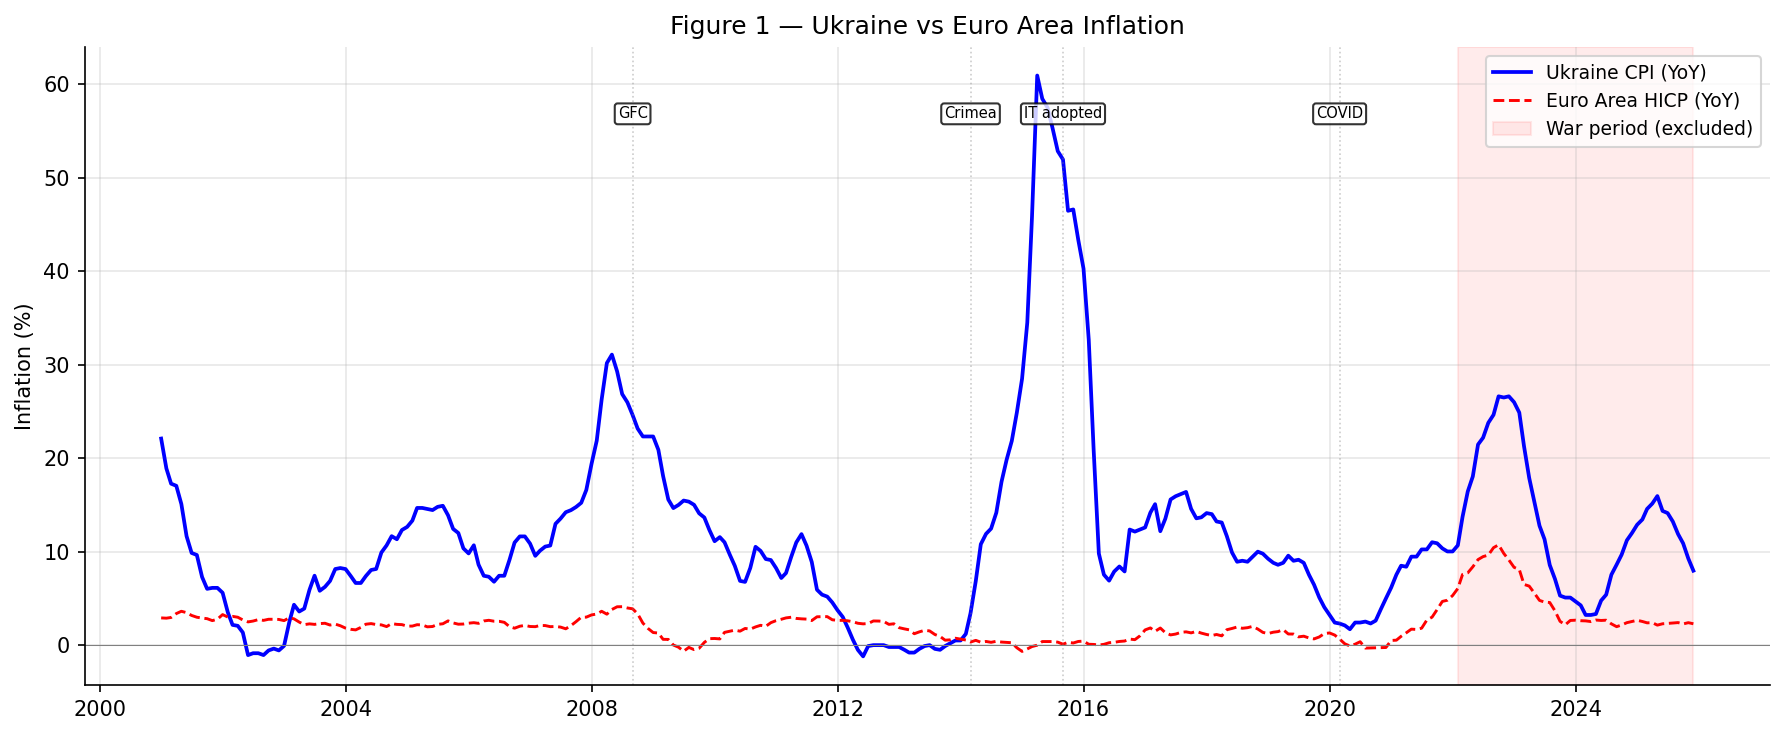

In [267]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_full["date"], df_full["ua_inflation"], "b-", lw=1.8, label="Ukraine CPI (YoY)")
ax.plot(df_full["date"], df_full["ea_inflation"], "r--", lw=1.4, label="Euro Area HICP (YoY)")
ax.axhline(0, color="grey", lw=0.5)
ax.axvspan(pd.Timestamp("2022-02-01"), df_full["date"].max(),
           alpha=0.08, color="red", label="War period (excluded)")

# Key events
for date, label in [("2008-09", "GFC"), ("2014-03", "Crimea"),
                     ("2015-09", "IT adopted"), ("2020-03", "COVID")]:
    xpos = pd.Timestamp(date)
    if df_full["date"].min() <= xpos <= df_full["date"].max():
        ax.axvline(xpos, color="grey", ls=":", alpha=0.4, lw=0.8)
        ax.text(xpos, ax.get_ylim()[1] * 0.88 if ax.get_ylim()[1] > 20 else 55,
                label, fontsize=7, ha="center",
                bbox=dict(fc="white", alpha=0.8, boxstyle="round,pad=0.2"))

ax.set_ylabel("Inflation (%)")
ax.set_title("Figure 1 — Ukraine vs Euro Area Inflation", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
savefig("01_inflation_comparison.png")
plt.show()


### 3.2 Summary statistics (pre-war sample)

In [268]:
desc = df_pre[["ua_inflation", "ea_inflation"]].describe().T
desc["skewness"] = df_pre[["ua_inflation", "ea_inflation"]].skew().values
desc["kurtosis"] = df_pre[["ua_inflation", "ea_inflation"]].kurt().values
print("Table 2 — Descriptive Statistics (2001–2021)\n")
print(desc.to_string(float_format="%.2f"))

Table 2 — Descriptive Statistics (2001–2021)

              count  mean   std   min  25%  50%   75%   max  skewness  kurtosis
ua_inflation 252.00 11.56 10.91 -1.20 5.92 9.66 14.16 60.91      2.23      6.33
ea_inflation 252.00  1.72  1.11 -0.67 0.76 1.86  2.56  4.80     -0.07     -0.53



### 3.3 Scatter plot by sub-period 

  → Saved: 02_scatter_subperiod.png


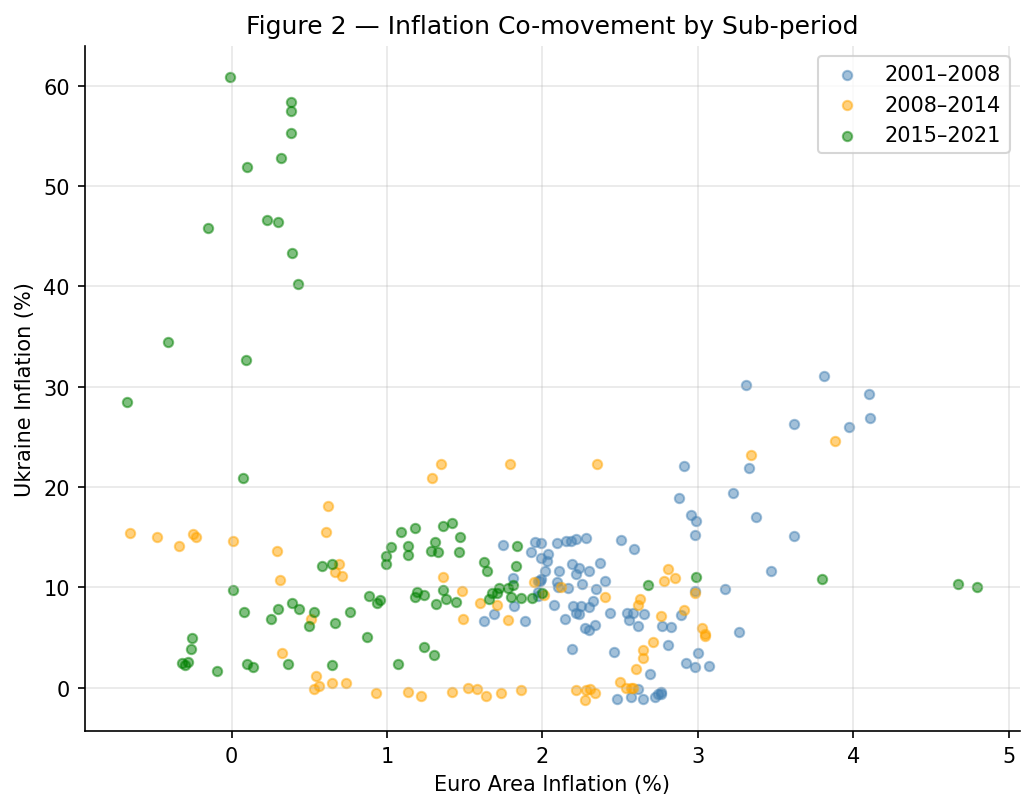

In [269]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sub_periods = {
    "2001–2008": ("2001-01", "2008-08", "steelblue"),
    "2008–2014": ("2008-09", "2014-05", "orange"),
    "2015–2021": ("2015-01", "2021-12", "green"),
}
for label, (s, e, col) in sub_periods.items():
    mask = (df_pre["date"] >= s) & (df_pre["date"] <= e)
    sub = df_pre.loc[mask]
    ax.scatter(sub["ea_inflation"], sub["ua_inflation"],
               alpha=0.5, label=label, color=col, s=20)

ax.set_xlabel("Euro Area Inflation (%)")
ax.set_ylabel("Ukraine Inflation (%)")
ax.set_title("Figure 2 — Inflation Co-movement by Sub-period")
ax.legend()
savefig("02_scatter_subperiod.png")
plt.show()


### 3.4 Rolling correlation

  → Saved: 03_rolling_correlation.png


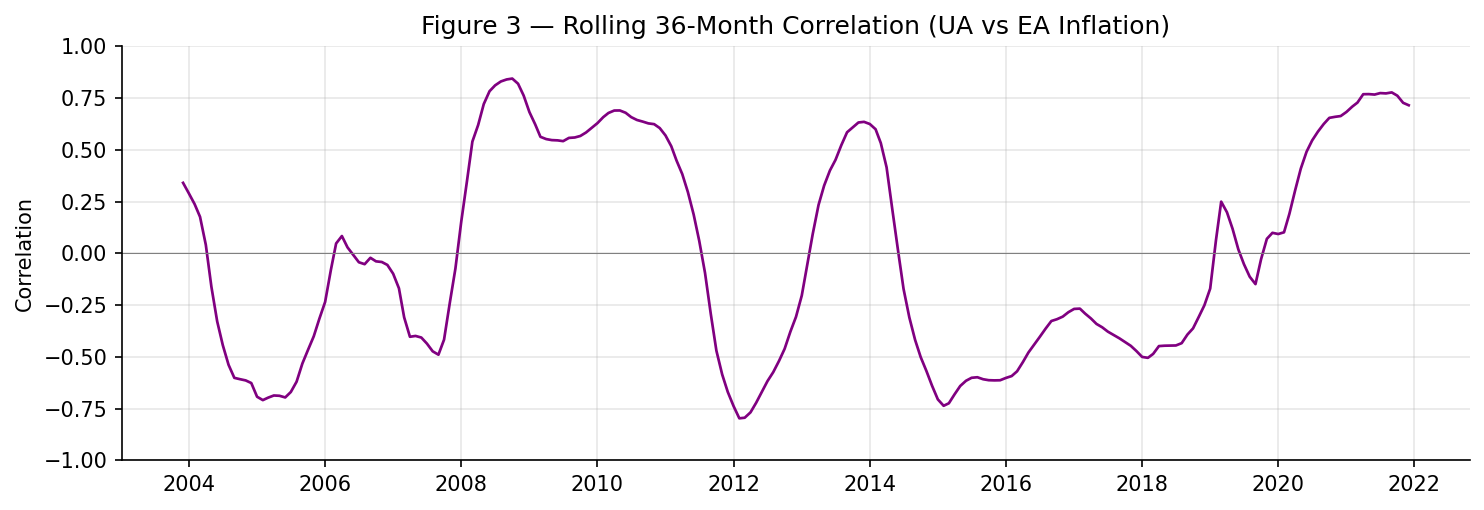

In [270]:
df_pre_idx = df_pre.set_index("date")
roll_corr = df_pre_idx["ua_inflation"].rolling(36).corr(df_pre_idx["ea_inflation"])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(roll_corr.index, roll_corr, "purple", lw=1.3)
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylim(-1, 1)
ax.set_ylabel("Correlation")
ax.set_title("Figure 3 — Rolling 36-Month Correlation (UA vs EA Inflation)")
savefig("03_rolling_correlation.png")
plt.show()

### 3.5 Inflation volatility 

  → Saved: 04_volatility_comparison.png


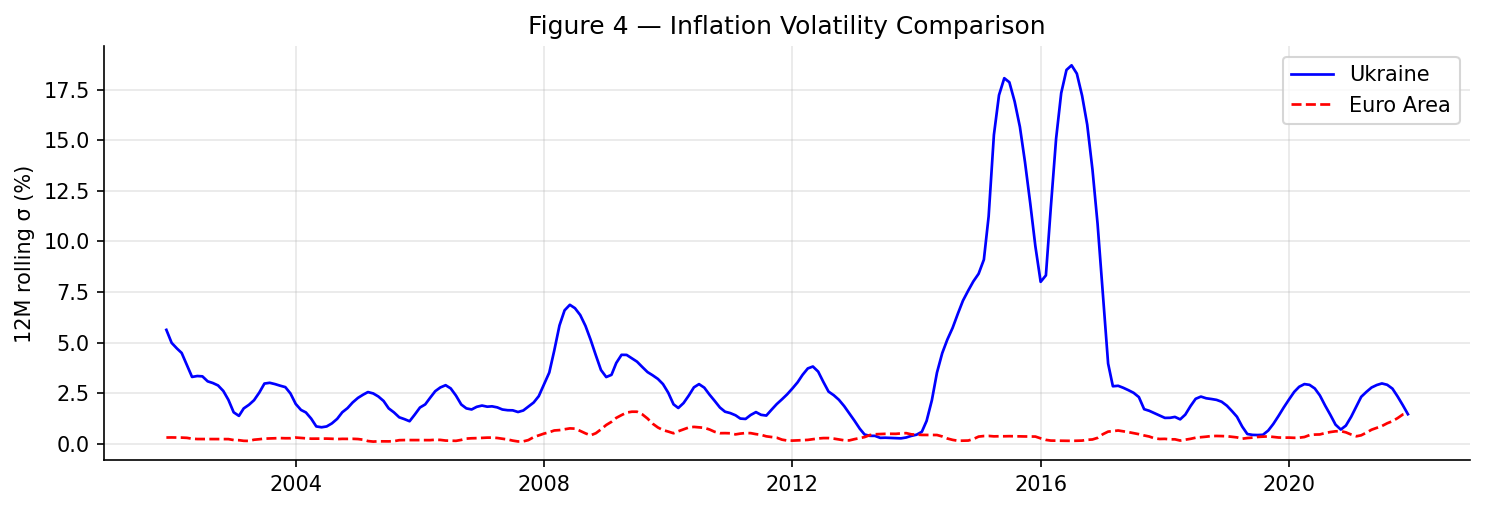

In [271]:
vol_ua = df_pre_idx["ua_inflation"].rolling(12).std()
vol_ea = df_pre_idx["ea_inflation"].rolling(12).std()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(vol_ua.index, vol_ua, "b-", lw=1.3, label="Ukraine")
ax.plot(vol_ea.index, vol_ea, "r--", lw=1.3, label="Euro Area")
ax.set_ylabel("12M rolling σ (%)")
ax.set_title("Figure 4 — Inflation Volatility Comparison")
ax.legend()
savefig("04_volatility_comparison.png")
plt.show()

## 4. Stationarity Tests

In [272]:
adf_results = pd.concat([
    adf_table(df_pre["ua_inflation"], "UA inflation (YoY)"),
    adf_table(df_pre["ea_inflation"], "EA inflation (YoY)"),
], ignore_index=True)

print("Table 3 — Augmented Dickey-Fuller Tests (pre-war sample)\n")
display(adf_results)

# Note: if EA inflation is borderline, we also run on first differences
ea_diff_p = adfuller(df_pre["ea_inflation"].diff().dropna(), autolag="AIC")[1]
print(f"\nΔ(EA inflation) ADF p-value: {ea_diff_p:.4f}")
print("Both series are treated as stationary in levels for the VAR.")
print("EA inflation is borderline I(1); robustness with first differences")
print("is checked in Section 8.")

Table 3 — Augmented Dickey-Fuller Tests (pre-war sample)



,Variable,ADF stat,p-value,Lags,N,1%,5%,Stationary (5%)
0,UA inflation (YoY),-2.961,0.0387,13,238,-3.458,-2.874,Yes
1,EA inflation (YoY),-2.473,0.1222,12,239,-3.458,-2.874,No



Δ(EA inflation) ADF p-value: 0.0000
Both series are treated as stationary in levels for the VAR.
EA inflation is borderline I(1); robustness with first differences
is checked in Section 8.


## 5. Granger Causality Tests

In [273]:
print("Table 4 — Granger Causality Tests (max 4 lags)\n")
print("H₀: EA inflation does NOT Granger-cause UA inflation")
gc_ea_to_ua = grangercausalitytests(
    df_pre[["ua_inflation", "ea_inflation"]].dropna(), maxlag=4, verbose=True
)

print("\n" + "="*60)
print("\nH₀: UA inflation does NOT Granger-cause EA inflation")
gc_ua_to_ea = grangercausalitytests(
    df_pre[["ea_inflation", "ua_inflation"]].dropna(), maxlag=4, verbose=True
)

Table 4 — Granger Causality Tests (max 4 lags)

H₀: EA inflation does NOT Granger-cause UA inflation

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.1880  , p=0.0754  , df_denom=248, df_num=1
ssr based chi2 test:   chi2=3.2266  , p=0.0725  , df=1
likelihood ratio test: chi2=3.2060  , p=0.0734  , df=1
parameter F test:         F=3.1880  , p=0.0754  , df_denom=248, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.5737  , p=0.2094  , df_denom=245, df_num=2
ssr based chi2 test:   chi2=3.2115  , p=0.2007  , df=2
likelihood ratio test: chi2=3.1911  , p=0.2028  , df=2
parameter F test:         F=1.5737  , p=0.2094  , df_denom=245, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4294  , p=0.2348  , df_denom=242, df_num=3
ssr based chi2 test:   chi2=4.4121  , p=0.2203  , df=3
likelihood ratio test: chi2=4.3735  , p=0.2239  , df=3
parameter F test:         F=1.4294  , p=0.2348  , df_denom=242, df

## 6. Part B : Structural VAR Estimation

### Econometric framework

We estimate a bivariate VAR on the pre-war sample (2001–2021):

$$Y_t = c + A_1 Y_{t-1} + \cdots + A_p Y_{t-p} + u_t, \quad u_t \sim N(0, \Sigma_u)$$
where $Y_t = (\pi_t^{EA}, \; \pi_t^{UA})'$.

### Identification (Cholesky decomposition)

We recover structural shocks via the Cholesky factorisation of $\Sigma_u$:
$$u_t = P \varepsilon_t, \quad PP' = \Sigma_u, \quad \varepsilon_t \sim N(0, I)$$
**Ordering**: EA inflation is ordered first (block-exogenous to Ukraine —
small open economy assumption: Ukraine does not affect EA inflation
contemporaneously).

This yields two orthogonal structural shocks:
- $\varepsilon_1$: **Euro Area / external shock** — moves EA inflation on impact;
   transmits to UA with a lag or contemporaneously via the lower-triangular element.
- $\varepsilon_2$: **Ukraine-specific shock** — captures domestic monetary policy,
  exchange-rate adjustments, and idiosyncratic supply factors.

### Counterfactual logic

Under Euro Area membership, Ukraine would no longer experience idiosyncratic
monetary/exchange-rate shocks. The counterfactual replaces $\varepsilon_2^{UA}$
(Ukraine-specific shocks) with zero or with rescaled EA shocks, then
re-simulates the system using the estimated VAR coefficients.

### 6.1 Prepare estimation data

In [274]:
# Ordering: [ea_inflation, ua_inflation] — EA first (exogenous)
var_cols = ["ea_inflation", "ua_inflation"]
df_est = df_pre[["date"] + var_cols].dropna().reset_index(drop=True)
df_est_indexed = df_est.set_index("date")

print(f"Estimation sample: {len(df_est)} obs")
print(f"  {df_est['date'].iloc[0].strftime('%Y-%m')} → {df_est['date'].iloc[-1].strftime('%Y-%m')}")

Estimation sample: 252 obs
  2001-01 → 2021-12



### 6.2 Lag selection

In [275]:
model = VAR(df_est_indexed[var_cols])
lag_sel = model.select_order(maxlags=12)
print("Table 5 — Lag Selection Criteria\n")
print(lag_sel.summary())

p_bic = lag_sel.selected_orders.get("bic", 2)
p_aic = lag_sel.selected_orders.get("aic", 2)
p_opt = max(p_bic, 1)  # BIC preferred (parsimony)
print(f"\n→ Selected p = {p_opt} (BIC)")
print(f"  AIC suggests p = {p_aic} (used for robustness)")

Table 5 — Lag Selection Criteria

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        4.950       4.979       141.2       4.962
1       -1.021     -0.9341      0.3602     -0.9860
2       -1.623     -1.478*      0.1974     -1.564*
3       -1.622      -1.419      0.1976      -1.540
4       -1.600      -1.339      0.2019      -1.495
5       -1.624      -1.305      0.1971      -1.496
6       -1.621      -1.244      0.1978      -1.469
7       -1.617      -1.182      0.1985      -1.442
8      -1.713*      -1.220     0.1803*      -1.515
9       -1.692      -1.141      0.1843      -1.470
10      -1.679      -1.070      0.1868      -1.433
11      -1.680      -1.013      0.1866      -1.411
12      -1.667     -0.9421      0.1891      -1.375
--------------------------------------------------

→ Selected p = 2 (BIC)
  AIC suggests p = 8 (used for robustness)



### 6.3 VAR estimation

In [276]:
var_res = model.fit(maxlags=p_opt)
print(var_res.summary())

K = len(var_cols)
T_eff = var_res.nobs
print(f"\nEffective sample: {T_eff} observations (after losing {p_opt} lags)")


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 03, Apr, 2026
Time:                     02:59:13
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -1.52020
Nobs:                     250.000    HQIC:                  -1.60437
Log likelihood:          -491.837    FPE:                   0.189939
AIC:                     -1.66106    Det(Omega_mle):        0.182564
--------------------------------------------------------------------
Results for equation ea_inflation
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.057280         0.038620            1.483           0.138
L1.ea_inflation         1.261321         0.060891           20.714           0.000
L1.ua_inflation         0.012782         0.00


### 6.4 Residual diagnostics 

In [277]:

print("Table 6 — Residual Diagnostics\n")
print(f"{'Equation':<20} {'Ljung-Box(12) p':>18} {'Jarque-Bera p':>16} {'Status':>10}")
print("-" * 68)

for i, name in enumerate(var_res.names):
    resid_i = var_res.resid.values[:, i]
    lb = acorr_ljungbox(resid_i, lags=12, return_df=True)
    lb_min_p = lb["lb_pvalue"].min()
    jb_stat, jb_p, *_ = jarque_bera(resid_i)
    status = "✓" if lb_min_p > 0.05 else "⚠ autocorr"
    print(f"{name:<20} {lb_min_p:>18.4f} {jb_p:>16.4f} {status:>10}")


Table 6 — Residual Diagnostics

Equation                Ljung-Box(12) p    Jarque-Bera p     Status
--------------------------------------------------------------------
ea_inflation                     0.0000           0.0030 ⚠ autocorr
ua_inflation                     0.0000           0.0000 ⚠ autocorr



### 6.5 Cholesky identification 

In [278]:
Sigma_u = var_res.sigma_u
P = cholesky(Sigma_u, lower=True)
P_inv = np.linalg.inv(P)

print("Reduced-form covariance Σ_u:")
print(pd.DataFrame(Sigma_u, index=var_cols, columns=var_cols).to_string(float_format="%.6f"))
print("\nCholesky factor P (lower-triangular):")
print(pd.DataFrame(P, index=var_cols, columns=var_cols).to_string(float_format="%.6f"))
print(f"\nContemporaneous pass-through (P[1,0]/P[0,0]): "
      f"{P[1,0]/P[0,0]:.4f}")
print("  = 1pp EA inflation shock → immediate UA inflation response")

# Structural shocks
u = var_res.resid.values                # (T_eff, K)
eps = (P_inv @ u.T).T                 # (T_eff, K)
dates_eps = df_est_indexed.index[p_opt:]

eps_df = pd.DataFrame(eps, columns=["eps_EA", "eps_UA"], index=dates_eps)

# Verify orthogonality
cov_check = np.round(np.cov(eps.T), 4)
print("\nStructural shock covariance (should ≈ I):")
print(cov_check)

Reduced-form covariance Σ_u:
              ea_inflation  ua_inflation
ea_inflation      0.066525     -0.020772
ua_inflation     -0.020772      2.750786

Cholesky factor P (lower-triangular):
              ea_inflation  ua_inflation
ea_inflation      0.257924      0.000000
ua_inflation     -0.080535      1.656593

Contemporaneous pass-through (P[1,0]/P[0,0]): -0.3122
  = 1pp EA inflation shock → immediate UA inflation response

Structural shock covariance (should ≈ I):
[[0.9839 0.    ]
 [0.     0.9839]]


## 7. Impulse Response Functions

### 7.1 Orthogonalised IRFs with bootstrap CIs

Bootstrapping IRF confidence bands (500 replications)...
Done.
  → Saved: 05_irf_structural.png


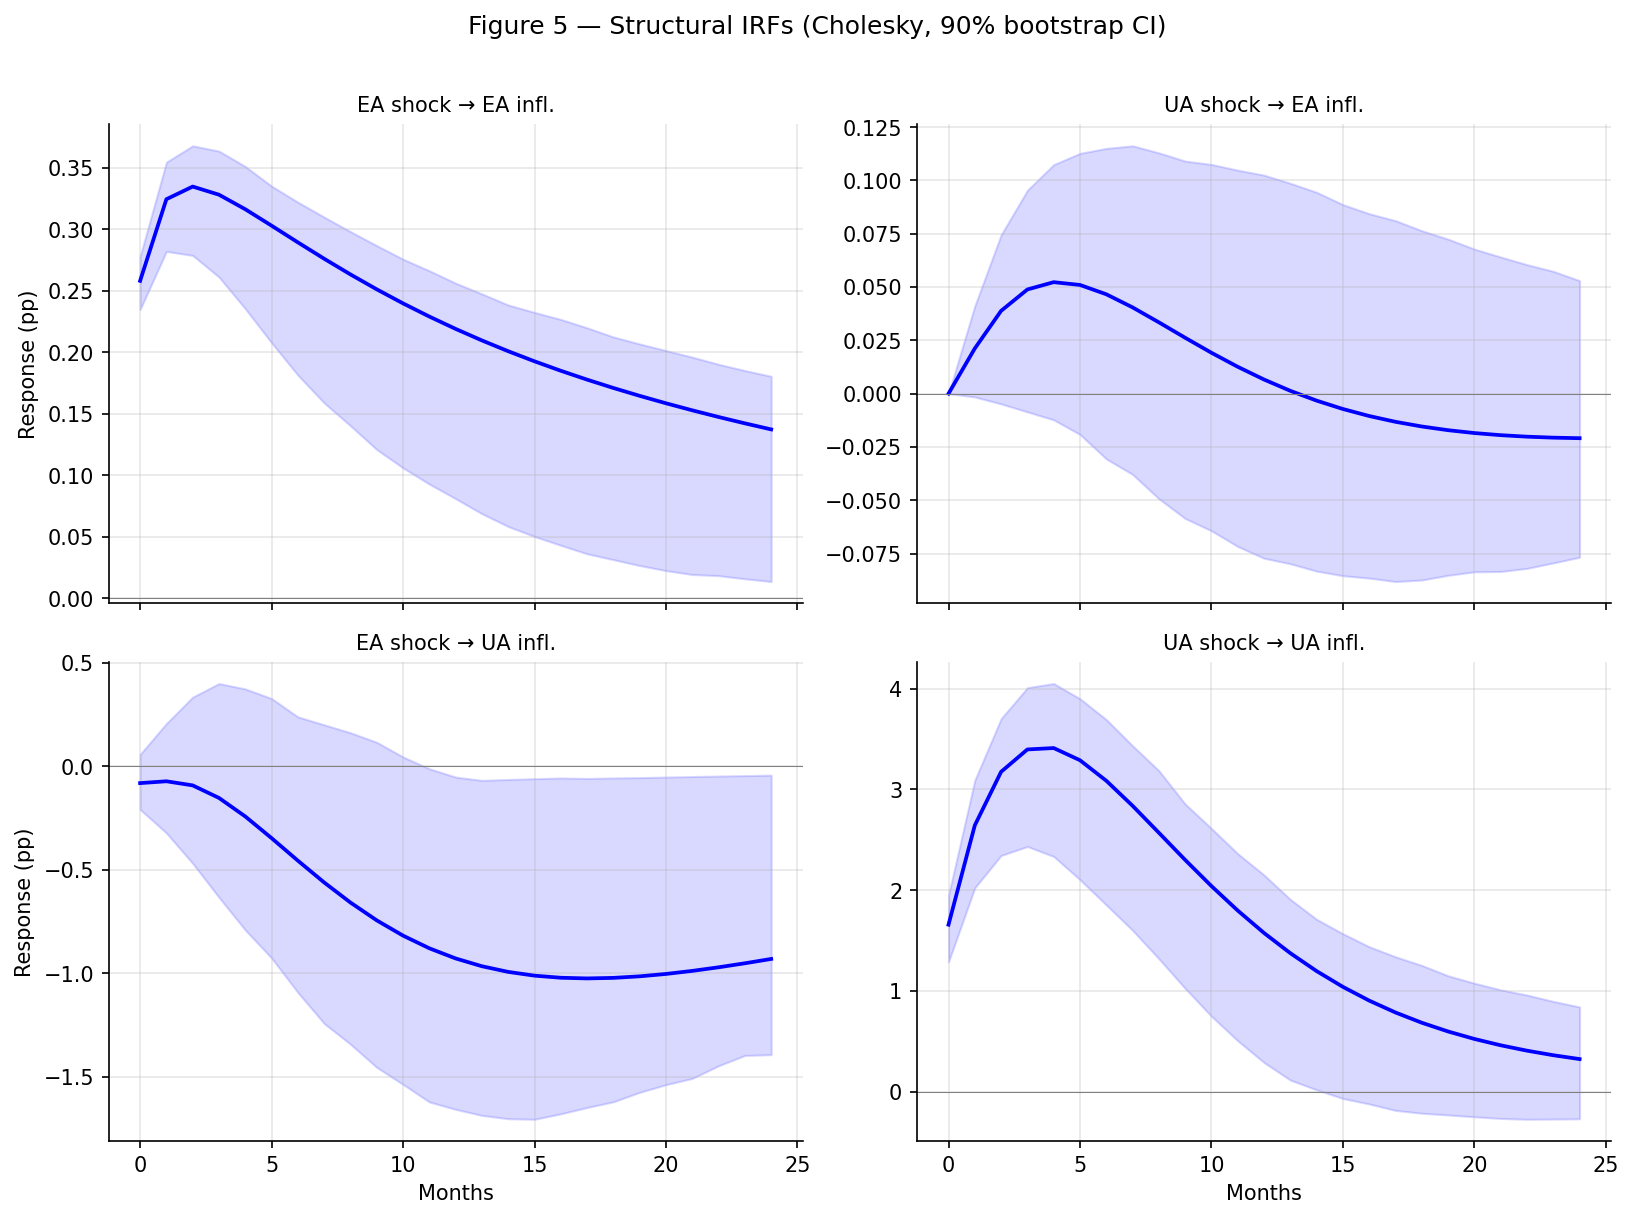

In [279]:
irf = var_res.irf(periods=24)
n_horizons = 25  # 0..24

# --- Manual bootstrap for confidence bands ---
def bootstrap_irfs(var_result, n_boot=500, periods=24):
    """Residual bootstrap for orthogonalised IRF confidence bands."""
    resid = var_result.resid.values if hasattr(var_result.resid, 'values') else var_result.resid
    T, K = resid.shape
    p = var_result.k_ar
    Y = np.asarray(var_result.endog)

    irfs_boot = np.zeros((n_boot, periods + 1, K, K))

    for b in range(n_boot):
        # Resample residuals
        idx = np.random.choice(T, size=T, replace=True)
        u_boot = resid[idx]

        # Simulate new data under the VAR
        Y_boot = np.zeros_like(Y)
        Y_boot[:p] = Y[:p]
        for t in range(p, len(Y)):
            Y_boot[t] = var_result.intercept.copy()
            for lag in range(p):
                Y_boot[t] += var_result.coefs[lag] @ Y_boot[t - 1 - lag]
            Y_boot[t] += u_boot[t - p]

        # Re-estimate VAR on bootstrapped data
        try:
            m_boot = VAR(Y_boot).fit(maxlags=p)
            irf_boot = m_boot.irf(periods=periods)
            irfs_boot[b] = irf_boot.orth_irfs
        except Exception:
            irfs_boot[b] = np.nan

    lo = np.nanpercentile(irfs_boot, 5, axis=0)
    hi = np.nanpercentile(irfs_boot, 95, axis=0)
    return lo, hi

print("Bootstrapping IRF confidence bands (500 replications)...")
irf_lo, irf_hi = bootstrap_irfs(var_res, n_boot=500, periods=24)
print("Done.")

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

titles = [
    ("EA shock → EA infl.", 0, 0),
    ("UA shock → EA infl.", 0, 1),
    ("EA shock → UA infl.", 1, 0),
    ("UA shock → UA infl.", 1, 1),
]

for resp_idx, imp_idx, (title, row, col) in zip(
    [0, 0, 1, 1], [0, 1, 0, 1], titles
):
    ax = axes[row, col]
    point = irf.orth_irfs[:, resp_idx, imp_idx]
    lo = irf_lo[:, resp_idx, imp_idx]
    hi = irf_hi[:, resp_idx, imp_idx]

    ax.plot(point, "b-", lw=1.8)
    ax.fill_between(range(len(point)), lo, hi, alpha=0.15, color="blue")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(title, fontsize=10)
    if row == 1:
        ax.set_xlabel("Months")
    if col == 0:
        ax.set_ylabel("Response (pp)")

fig.suptitle("Figure 5 — Structural IRFs (Cholesky, 90% bootstrap CI)", fontsize=12, y=1.01)
savefig("05_irf_structural.png")
plt.show()



### 7.2 Cumulative IRFs

  → Saved: 06_irf_cumulative.png


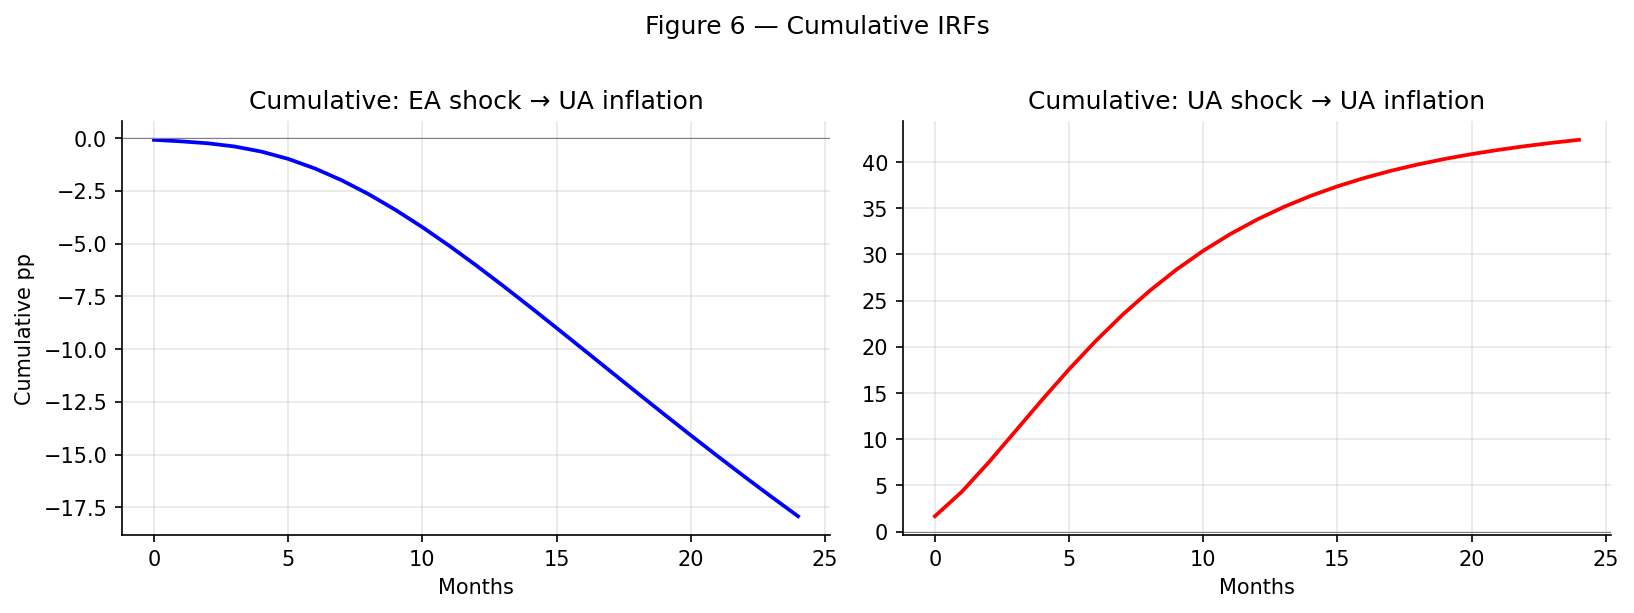

In [280]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

cum_irfs = np.cumsum(irf.orth_irfs, axis=0)

ax1.plot(cum_irfs[:, 1, 0], "b-", lw=1.8)
ax1.axhline(0, color="grey", lw=0.5)
ax1.set_title("Cumulative: EA shock → UA inflation")
ax1.set_xlabel("Months"); ax1.set_ylabel("Cumulative pp")

ax2.plot(cum_irfs[:, 1, 1], "r-", lw=1.8)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_title("Cumulative: UA shock → UA inflation")
ax2.set_xlabel("Months")

fig.suptitle("Figure 6 — Cumulative IRFs", fontsize=12, y=1.01)
savefig("06_irf_cumulative.png")
plt.show()

## 8. Historical Decomposition

In [281]:
def historical_decomposition(var_res, P_chol):
    """
    Decompose observed variables into cumulative contributions
    from each structural shock via the MA representation.
    """
    T = var_res.nobs
    K = len(var_res.names)
    p = var_res.k_ar
    coefs = var_res.coefs        # (p, K, K)
    P_inv = np.linalg.inv(P_chol)
    eps = (P_inv @ var_res.resid.values.T).T  # (T, K)

    # Build MA coefficient matrices Φ_s
    max_s = T
    Phi = np.zeros((max_s, K, K))
    Phi[0] = np.eye(K)
    for s in range(1, max_s):
        for j in range(min(s, p)):
            Phi[s] += coefs[j] @ Phi[s - 1 - j]

    # Contribution of shock j to variable i at time t
    contrib = np.zeros((K, T, K))  # (shock, time, variable)
    for j in range(K):
        e_j = np.zeros(K); e_j[j] = 1.0
        for t in range(T):
            for s in range(t + 1):
                contrib[j, t] += (Phi[s] @ P_chol @ e_j) * eps[t - s, j]

    return contrib, eps

print("Computing historical decomposition...")
contrib, eps_hd = historical_decomposition(var_res, P)
print("Done.")

Computing historical decomposition...
Done.



### 8.1 Plot: HD of Ukraine inflation

  → Saved: 07_historical_decomposition.png


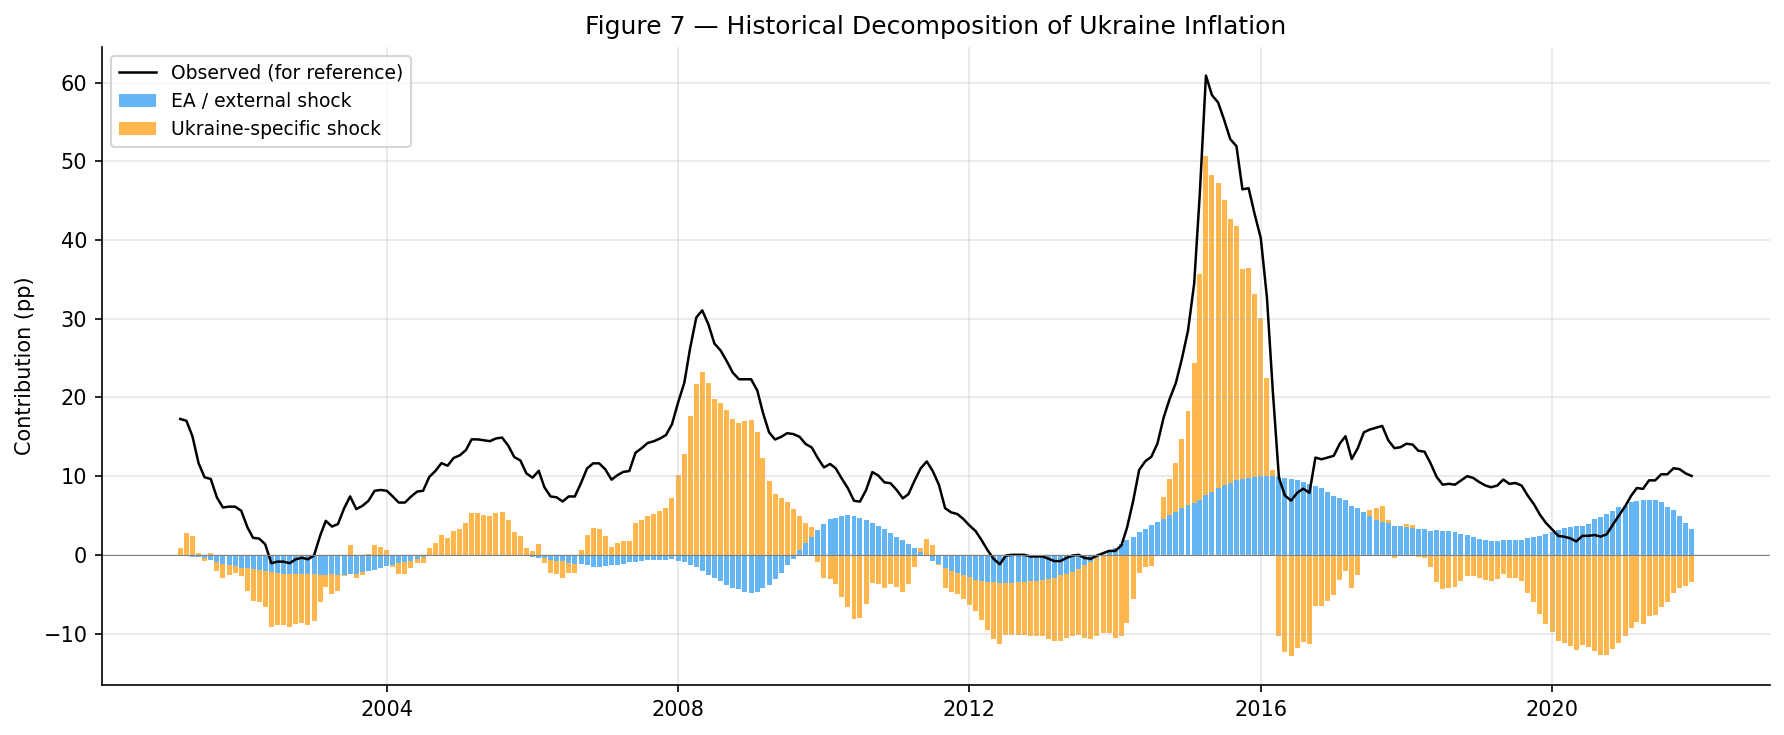

In [282]:
ua_idx = var_cols.index("ua_inflation")

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2196F3", "#FF9800"]
labels = ["EA / external shock", "Ukraine-specific shock"]
bottom_pos = np.zeros(T_eff)
bottom_neg = np.zeros(T_eff)

for j in range(K):
    c = contrib[j, :, ua_idx]
    pos = np.where(c > 0, c, 0)
    neg = np.where(c < 0, c, 0)
    ax.bar(dates_eps, pos, bottom=bottom_pos, width=25,
           color=colors[j], alpha=0.7, label=labels[j])
    ax.bar(dates_eps, neg, bottom=bottom_neg, width=25,
           color=colors[j], alpha=0.7)
    bottom_pos += pos
    bottom_neg += neg

# Overlay the demeaned observed inflation (HD explains deviations from forecast baseline)
observed_demean = df_est_indexed["ua_inflation"].iloc[p_opt:].values
ax.plot(dates_eps, observed_demean, "k-", lw=1.2, label="Observed (for reference)")

ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("Contribution (pp)")
ax.set_title("Figure 7 — Historical Decomposition of Ukraine Inflation", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
savefig("07_historical_decomposition.png")
plt.show()


### 8.2 Structural shock series

  → Saved: 08_structural_shocks.png


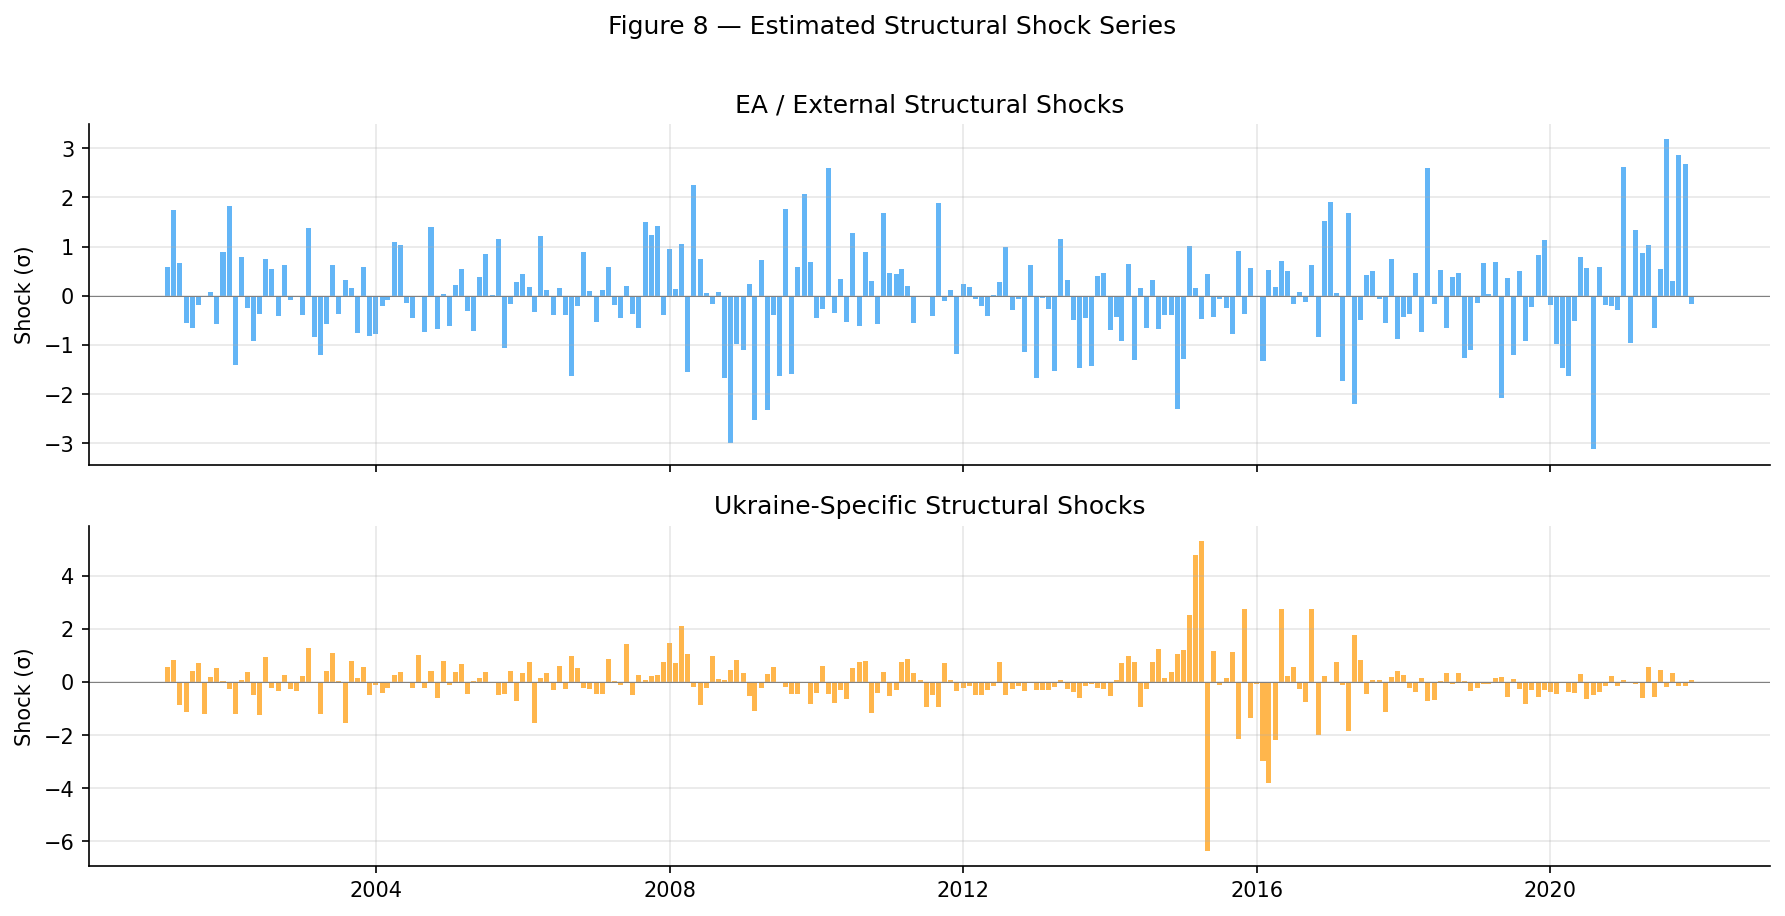

In [283]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.bar(dates_eps, eps_df["eps_EA"], width=25, color="#2196F3", alpha=0.7)
ax1.axhline(0, color="grey", lw=0.5)
ax1.set_ylabel("Shock (σ)")
ax1.set_title("EA / External Structural Shocks")

ax2.bar(dates_eps, eps_df["eps_UA"], width=25, color="#FF9800", alpha=0.7)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_ylabel("Shock (σ)")
ax2.set_title("Ukraine-Specific Structural Shocks")

fig.suptitle("Figure 8 — Estimated Structural Shock Series", fontsize=12, y=1.01)
savefig("08_structural_shocks.png")
plt.show()

## 9. Counterfactual Simulation
### Methodology

Under Euro Area membership, Ukraine would not experience its own
idiosyncratic monetary/exchange-rate shocks ($\varepsilon_2 = 0$),
and would instead be subject only to EA-wide shocks ($\varepsilon_1$).

We construct three scenarios:

| Scenario | Modification | Interpretation |
|----------|-------------|----------------|
| **A (main)** | $\varepsilon_2^{UA} = 0$ | No idiosyncratic shocks; only EA transmission |
| B | $\varepsilon_2^{UA} = \varepsilon_1^{EA}$ (rescaled) | UA responds to EA shocks like an EA member |
| C | Both $\varepsilon_1, \varepsilon_2 = \varepsilon_1^{EA}$ | Full EA integration |

In [284]:
def simulate_counterfactual(var_result, eps_modified, P_chol):
    """
    Re-simulate the VAR with modified structural shocks.

    Parameters
    ----------
    var_result : VARResults
    eps_modified : (T, K) array of modified structural shocks
    P_chol : (K, K) Cholesky factor

    Returns
    -------
    Y_cf : (T, K) counterfactual variable paths
    """
    T, K = eps_modified.shape
    p = var_result.k_ar
    coefs = var_result.coefs
    intercept = var_result.intercept
    Y_data = np.asarray(var_result.endog)  # (T+p, K) — includes initial lags

    # Modified reduced-form residuals
    u_cf = (P_chol @ eps_modified.T).T

    # Simulate
    Y_cf = np.zeros((T + p, K))
    Y_cf[:p] = Y_data[:p]  # same initial conditions

    for t in range(p, T + p):
        Y_cf[t] = intercept.copy()
        for lag in range(p):
            Y_cf[t] += coefs[lag] @ Y_cf[t - 1 - lag]
        Y_cf[t] += u_cf[t - p]

    return Y_cf[p:]


### 9.1 Scenario A (main): zero out Ukraine-specific shocks

In [285]:
eps_A = eps.copy()
eps_A[:, 1] = 0.0  # kill Ukraine-specific shocks

Y_cf_A = simulate_counterfactual(var_res, eps_A, P)

# %%
# === 9.2 Scenario B: replace UA shocks with rescaled EA shocks ===
eps_B = eps.copy()
std_ratio = eps[:, 1].std() / eps[:, 0].std()
eps_B[:, 1] = eps[:, 0] * std_ratio  # rescale EA shocks to UA scale

Y_cf_B = simulate_counterfactual(var_res, eps_B, P)


### 9.3 Observed data for comparison 

In [286]:
observed = df_est_indexed[var_cols].iloc[p_opt:].values
dates_cf = dates_eps

### 9.4 MAIN FIGURE

  → Saved: 09_counterfactual_main.png


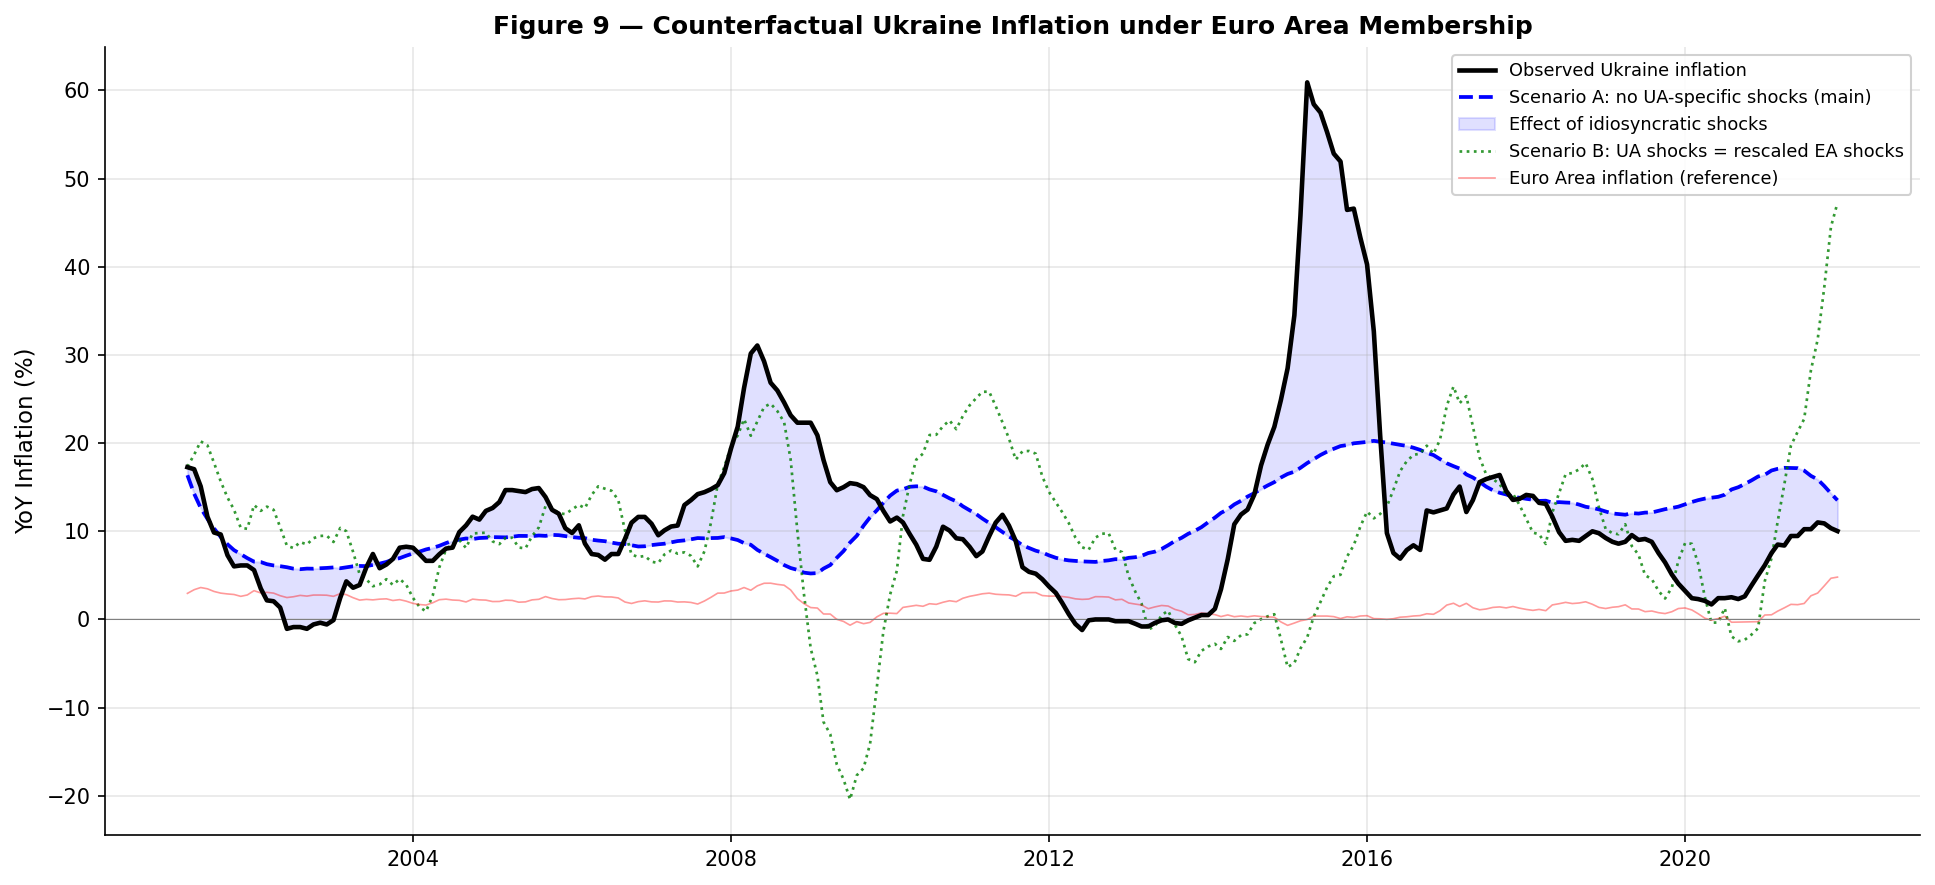

In [287]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(dates_cf, observed[:, 1], "k-", lw=2.2,
        label="Observed Ukraine inflation", zorder=5)

ax.plot(dates_cf, Y_cf_A[:, 1], "b--", lw=1.8,
        label="Scenario A: no UA-specific shocks (main)")

ax.fill_between(dates_cf, observed[:, 1], Y_cf_A[:, 1],
                alpha=0.12, color="blue",
                label="Effect of idiosyncratic shocks")

ax.plot(dates_cf, Y_cf_B[:, 1], "g:", lw=1.3, alpha=0.8,
        label="Scenario B: UA shocks = rescaled EA shocks")

ax.plot(dates_cf, observed[:, 0], "r-", lw=0.8, alpha=0.4,
        label="Euro Area inflation (reference)")

ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("YoY Inflation (%)", fontsize=11)
ax.set_title("Figure 9 — Counterfactual Ukraine Inflation under Euro Area Membership",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
savefig("09_counterfactual_main.png")
plt.show()

### 9.5 Inflation gap

  → Saved: 10_inflation_gap.png


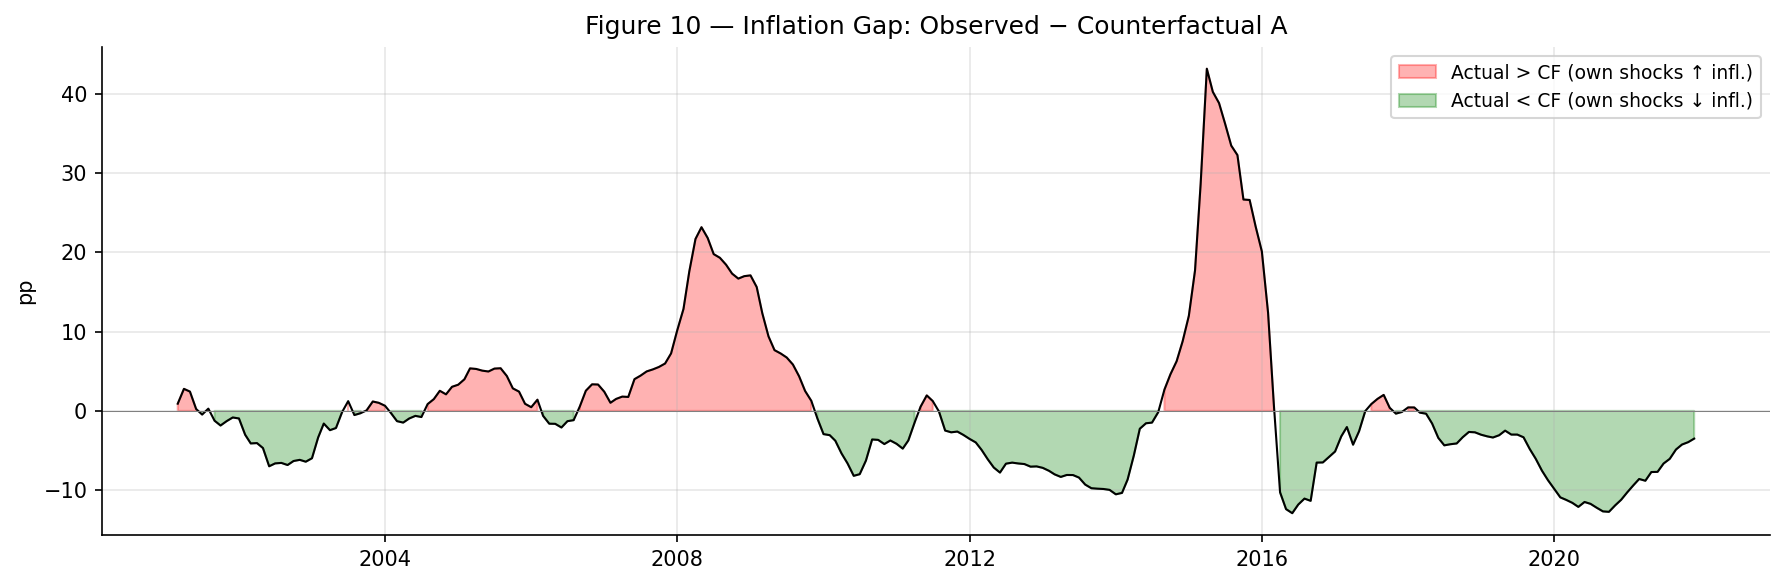

In [288]:
gap_A = observed[:, 1] - Y_cf_A[:, 1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dates_cf, gap_A, 0,
                where=gap_A > 0, color="red", alpha=0.3, label="Actual > CF (own shocks ↑ infl.)")
ax.fill_between(dates_cf, gap_A, 0,
                where=gap_A <= 0, color="green", alpha=0.3, label="Actual < CF (own shocks ↓ infl.)")
ax.plot(dates_cf, gap_A, "k-", lw=1)
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("pp")
ax.set_title("Figure 10 — Inflation Gap: Observed − Counterfactual A", fontsize=12)
ax.legend(fontsize=9)
savefig("10_inflation_gap.png")
plt.show()

### 9.6 Summary statistics

In [289]:
cf_summary = pd.DataFrame({
    "Observed UA": observed[:, 1],
    "CF-A (no UA shocks)": Y_cf_A[:, 1],
    "CF-B (EA shocks)": Y_cf_B[:, 1],
    "Euro Area": observed[:, 0],
}, index=dates_cf)

print("Table 7 — Counterfactual Summary Statistics\n")
print(cf_summary.describe().T.to_string(float_format="%.2f"))

# By sub-period
print("\n\nMean inflation gap (Observed − CF-A) by sub-period:")
for label, (s, e) in [("2001–2008", ("2001", "2008")),
                        ("2008–2014", ("2008-09", "2014-05")),
                        ("2015–2021", ("2015", "2021"))]:
    mask = (cf_summary.index >= s) & (cf_summary.index <= e)
    sub = cf_summary.loc[mask]
    if len(sub) > 0:
        diff = sub["Observed UA"].mean() - sub["CF-A (no UA shocks)"].mean()
        print(f"  {label}: {diff:+.2f} pp (N={len(sub)})")


Table 7 — Counterfactual Summary Statistics

                     count  mean   std    min  25%  50%   75%   max
Observed UA         250.00 11.48 10.92  -1.20 5.92 9.60 14.11 60.91
CF-A (no UA shocks) 250.00 11.29  4.12   5.21 7.95 9.81 14.23 20.25
CF-B (EA shocks)    250.00  9.78  9.87 -20.43 3.95 9.66 15.92 47.24
Euro Area           250.00  1.71  1.11  -0.67 0.74 1.85  2.54  4.80


Mean inflation gap (Observed − CF-A) by sub-period:
  2001–2008: +0.47 pp (N=83)
  2008–2014: -2.00 pp (N=69)
  2015–2021: +0.87 pp (N=73)


## 10. Robustness Checks

### 10.1 Robustness: alternative lag orders 

  → Saved: 11_robustness_lags.png


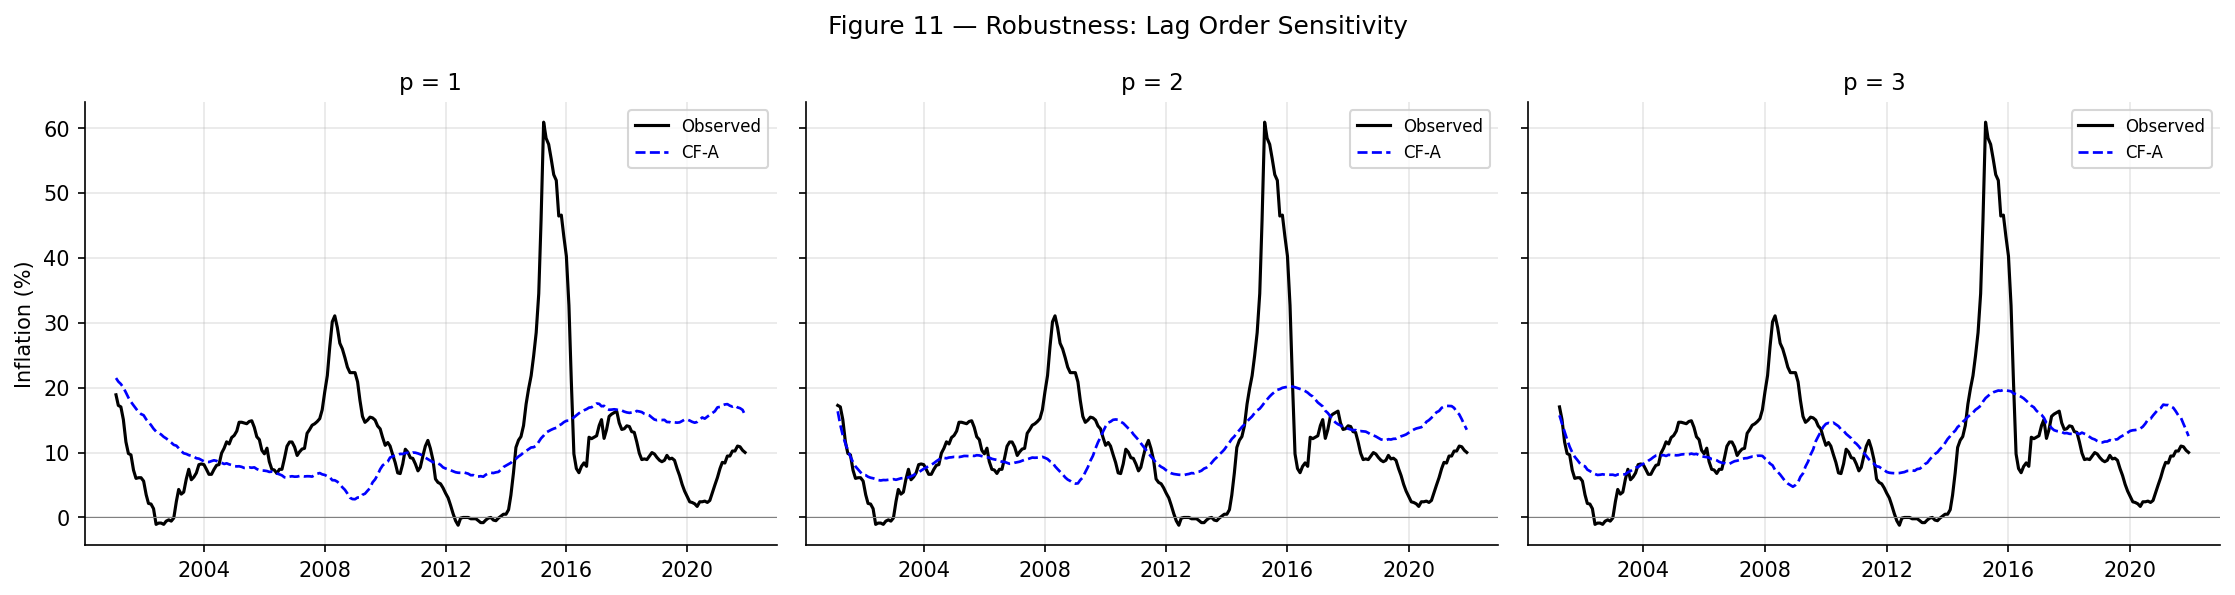

In [290]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, p_alt in enumerate([max(1, p_opt - 1), p_opt, min(12, p_opt + 1)]):
    ax = axes[idx]
    try:
        var_alt = model.fit(maxlags=p_alt)
        P_alt = cholesky(var_alt.sigma_u, lower=True)
        P_inv_alt = np.linalg.inv(P_alt)
        eps_alt = (P_inv_alt @ var_alt.resid.values.T).T

        eps_alt_cf = eps_alt.copy()
        eps_alt_cf[:, 1] = 0.0
        Y_alt = simulate_counterfactual(var_alt, eps_alt_cf, P_alt)

        d_alt = df_est_indexed.index[p_alt:]
        obs_alt = df_est_indexed["ua_inflation"].iloc[p_alt:].values

        ax.plot(d_alt, obs_alt, "k-", lw=1.5, label="Observed")
        ax.plot(d_alt, Y_alt[:, 1], "b--", lw=1.3, label="CF-A")
        ax.set_title(f"p = {p_alt}", fontsize=11)
        ax.axhline(0, color="grey", lw=0.5)
        ax.legend(fontsize=8)
        if idx == 0:
            ax.set_ylabel("Inflation (%)")
    except Exception as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha="center", fontsize=8)

fig.suptitle("Figure 11 — Robustness: Lag Order Sensitivity", fontsize=12)
savefig("11_robustness_lags.png")
plt.show()


### 10.2 Robustness: reverse Cholesky ordering

  → Saved: 12_robustness_ordering.png


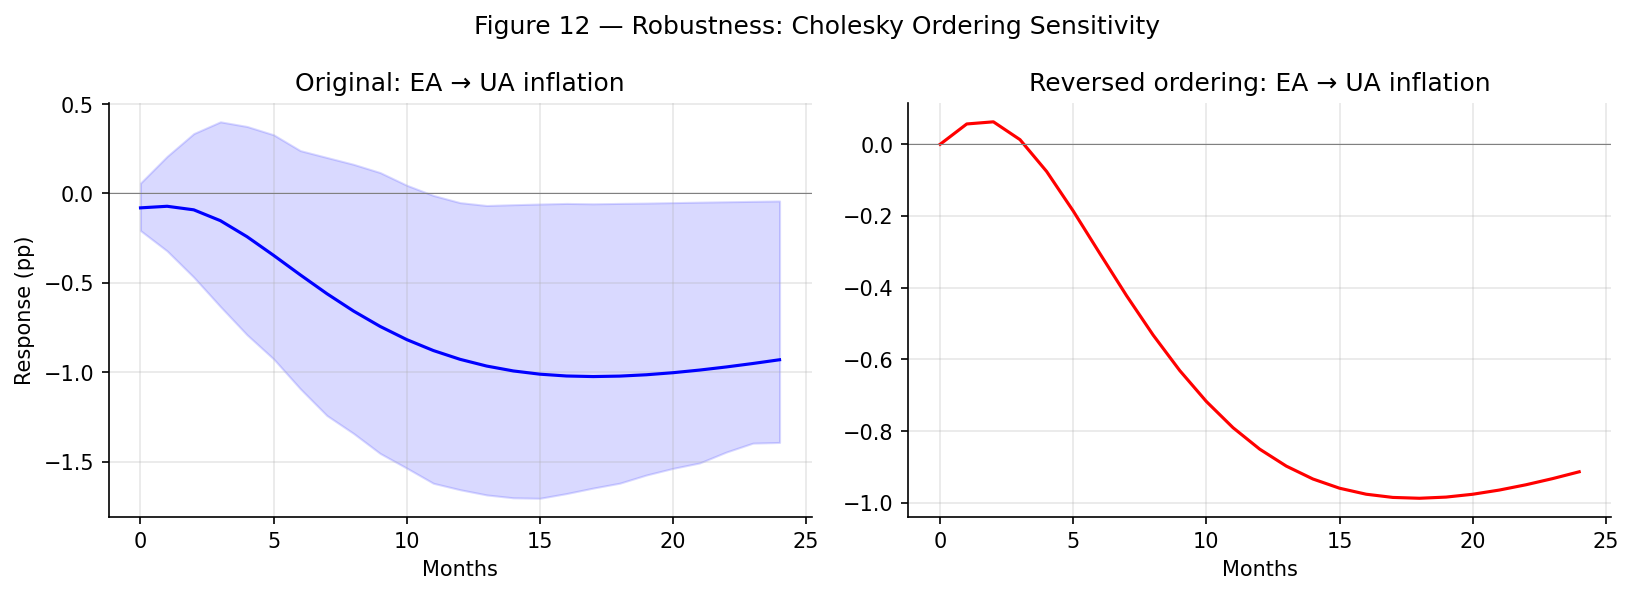

In [291]:
var_cols_rev = ["ua_inflation", "ea_inflation"]  # UA first
model_rev = VAR(df_est_indexed[var_cols_rev])
var_rev = model_rev.fit(maxlags=p_opt)

irf_rev = var_rev.irf(periods=24)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Original: EA shock → UA inflation (with bootstrap CIs from earlier)
resp_orig = irf.orth_irfs[:, 1, 0]
ax1.plot(resp_orig, "b-", lw=1.5)
ax1.fill_between(range(n_horizons), irf_lo[:, 1, 0], irf_hi[:, 1, 0],
                 alpha=0.15, color="blue")
ax1.axhline(0, color="grey", lw=0.5)
ax1.set_title("Original: EA → UA inflation")
ax1.set_xlabel("Months"); ax1.set_ylabel("Response (pp)")

# Reversed: EA shock → UA inflation (EA is now shock 1 in reversed order)
resp_rev = irf_rev.orth_irfs[:, 0, 1]  # UA is var 0, EA shock is 1
ax2.plot(resp_rev, "r-", lw=1.5)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_title("Reversed ordering: EA → UA inflation")
ax2.set_xlabel("Months")

fig.suptitle("Figure 12 — Robustness: Cholesky Ordering Sensitivity", fontsize=12)
savefig("12_robustness_ordering.png")
plt.show()


### 10.3 Robustness: sub-sample stability

  → Saved: 13_robustness_subsample.png


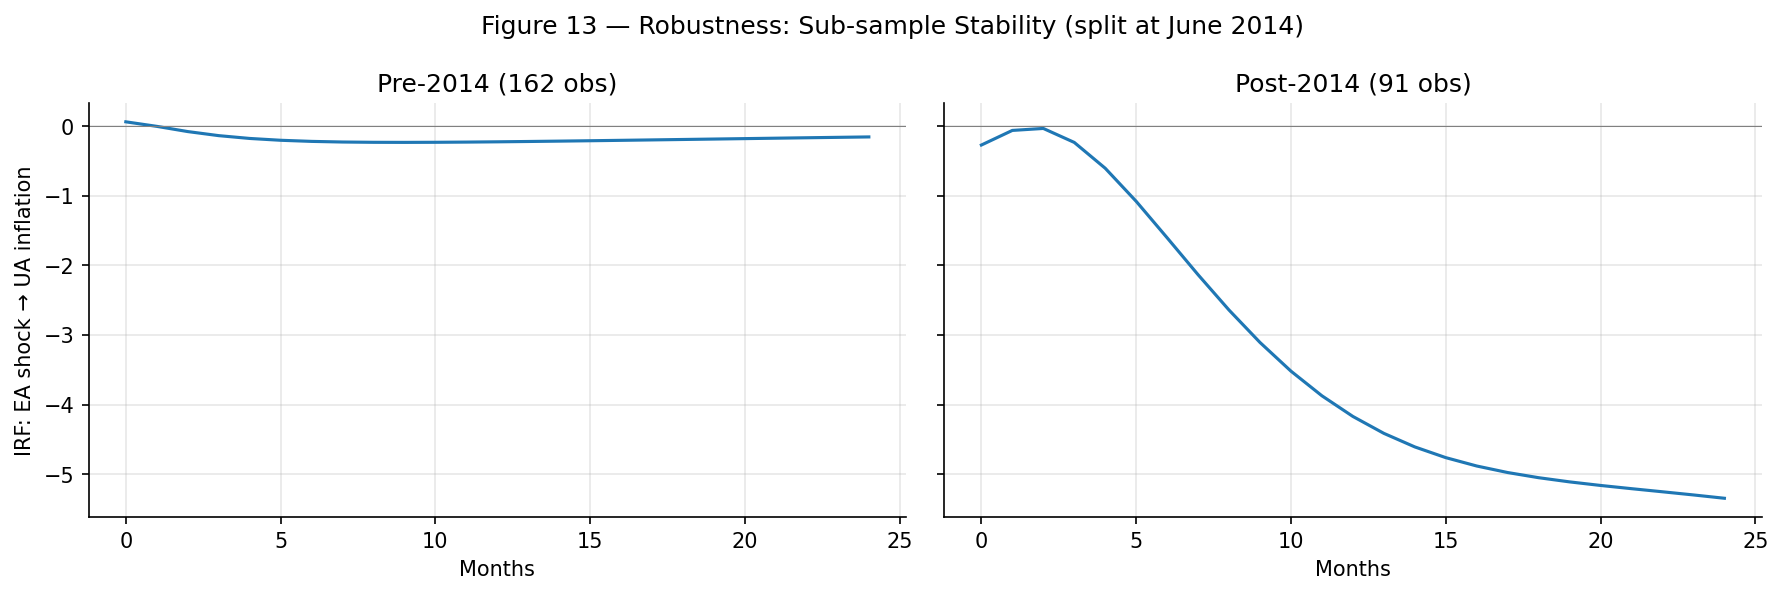

In [292]:
SPLIT = "2014-06-01"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for sub_df, label, ax in [
    (df_est_indexed.loc[:SPLIT], f"Pre-2014 ({len(df_est_indexed.loc[:SPLIT])} obs)", ax1),
    (df_est_indexed.loc[SPLIT:], f"Post-2014 ({len(df_est_indexed.loc[SPLIT:])} obs)", ax2)
]:
    if len(sub_df) > 2 * K + p_opt + 10:
        try:
            m = VAR(sub_df[var_cols]).fit(maxlags=min(p_opt, len(sub_df) // 6))
            i = m.irf(periods=24)
            ax.plot(i.orth_irfs[:, 1, 0], lw=1.5)
            ax.axhline(0, color="grey", lw=0.5)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes, ha="center")
    else:
        ax.text(0.5, 0.5, "Too few obs", transform=ax.transAxes, ha="center")
    ax.set_title(label)
    ax.set_xlabel("Months")
    if ax == ax1:
        ax.set_ylabel("IRF: EA shock → UA inflation")

fig.suptitle("Figure 13 — Robustness: Sub-sample Stability (split at June 2014)", fontsize=12)
savefig("13_robustness_subsample.png")
plt.show()

### 10.4 Robustness: first-differenced specification

  → Saved: 14_robustness_diff.png


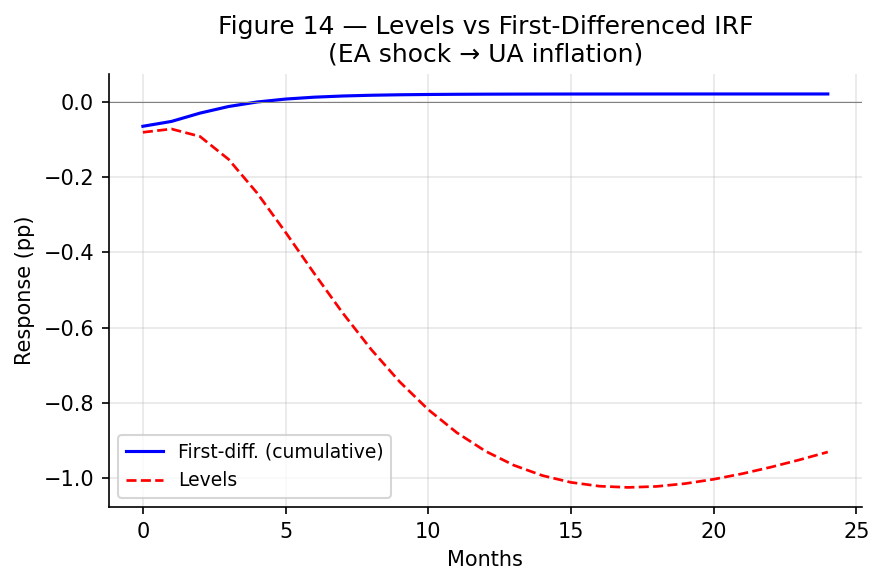

In [293]:
df_diff = df_est_indexed[var_cols].diff().dropna()
model_diff = VAR(df_diff)
p_diff = max(model_diff.select_order(maxlags=8).selected_orders.get("bic", 1), 1)
var_diff = model_diff.fit(maxlags=p_diff)
irf_diff = var_diff.irf(periods=24)

fig, ax = plt.subplots(figsize=(6, 4))
# Cumulative IRF of differenced model ≈ level IRF
cum_diff = np.cumsum(irf_diff.orth_irfs[:, 1, 0])
ax.plot(cum_diff, "b-", lw=1.5, label="First-diff. (cumulative)")
ax.plot(irf.orth_irfs[:, 1, 0], "r--", lw=1.3, label="Levels")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Months")
ax.set_ylabel("Response (pp)")
ax.set_title("Figure 14 — Levels vs First-Differenced IRF\n(EA shock → UA inflation)")
ax.legend(fontsize=9)
savefig("14_robustness_diff.png")
plt.show()

## 11. Discussion & Conclusion

### 11.1 Main findings

The SVAR-based counterfactual reveals three key insights:

1. **Ukraine-specific shocks are the dominant driver of inflation volatility.**
The historical decomposition shows that idiosyncratic shocks (monetary
policy, exchange rate, domestic supply disruptions) account for the bulk
of inflation fluctuations, particularly during the 2008–2009 and 2014–2015
crises.

2. **Under Euro Area membership, inflation would have been substantially
smoother.** Scenario A (no idiosyncratic shocks) produces a counterfactual
path with lower volatility, especially during crisis episodes where
exchange-rate depreciation amplified domestic price pressures.

3. **The gap narrows after 2016**, consistent with the NBU's adoption of
inflation targeting. This suggests that the IT reform partially achieved
what euro adoption would have delivered — a more stable nominal anchor.

### 11.2 The Lucas Critique

A fundamental limitation of this exercise is the **Lucas Critique**
(Lucas, 1976). The VAR coefficients are estimated under the *actual*
monetary regime (NBU policy, floating hryvnia). If Ukraine joined the
Euro Area, agents would **re-optimise**: wage-setters would anchor to
the ECB's 2% target; firms would adjust pricing under a fixed exchange
rate; financial markets would reprice sovereign risk.

These behavioural changes would **alter the VAR parameters themselves**,
meaning our counterfactual is a **partial-equilibrium** thought experiment.
It quantifies the *mechanical* contribution of idiosyncratic shocks to
inflation volatility, but does not capture the general-equilibrium
effects of regime change. A full treatment would require a DSGE model
with explicit regime switching, which is beyond the scope of this analysis.

Despite this limitation, the exercise is informative: it provides a
first-order approximation of the stabilisation benefits (and costs)
of monetary union membership for a transition economy.

### 11.3 Limitations and extensions

- **Bivariate system**: a richer model would include output, interest
rates, and exchange rates. The data constraint (short Ukraine IP series)
limits us to a bivariate specification.
- **Sign restrictions** (instead of Cholesky) would avoid imposing
a recursive ordering.
- **Synthetic control** (Abadie et al., 2010) could provide a
complementary cross-sectional counterfactual.
- The **2022+ wartime period** is excluded from estimation but could
serve as a dramatic out-of-sample case study.

### References

- Blanchard, O. & Quah, D. (1989). "The Dynamic Effects of Aggregate
Demand and Supply Disturbances." *AER*, 79(4).
- Jordà, Ò. (2005). "Estimation and Inference of Impulse Responses by
Local Projections." *AER*, 95(1).
- Kilian, L. & Lütkepohl, H. (2017). *Structural Vector Autoregressive
Analysis*. Cambridge University Press.
- Lucas, R. (1976). "Econometric Policy Evaluation: A Critique."
*Carnegie-Rochester Conference Series*, 1.
- Lütkepohl, H. (2005). *New Introduction to Multiple Time Series
Analysis*. Springer.

### 12. Export results

In [294]:
regime_table.to_csv(OUT_DIR / "table1_regime.csv", index=False)
adf_results.to_csv(OUT_DIR / "table3_adf.csv", index=False)
eps_df.to_csv(OUT_DIR / "structural_shocks.csv")
cf_summary.to_csv(OUT_DIR / "counterfactual_results.csv")

print("All results exported to output/")
print("\nFigures saved:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}")

All results exported to output/

Figures saved:
  01_inflation_comparison.png
  02_scatter_subperiod.png
  03_rolling_correlation.png
  04_volatility_comparison.png
  05_irf_structural.png
  06_irf_cumulative.png
  07_historical_decomposition.png
  08_structural_shocks.png
  09_counterfactual_main.png
  10_inflation_gap.png
  11_robustness_lags.png
  12_robustness_ordering.png
  13_robustness_subsample.png
  14_robustness_diff.png
